# Math 303 Final Project

**Adaptive Ant Colony Optimization (AACO)** + **Hybrid AACO→SQP** with **Built-in vs Scratch** comparison.

This notebook runs reproducible experiments and exports:
- Convergence plots (PDF/PNG)
- Boxplots for robustness (PDF/PNG)
- CSV summary tables for the IEEE paper


## 1. Imports and setup

In [15]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Callable, List, Tuple, Dict

# Built-in optimizer baselines (ready-made package)
from scipy.optimize import minimize

# Reproducibility
GLOBAL_SEED = 42
rng_global = np.random.default_rng(GLOBAL_SEED)

OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({'figure.figsize': (7.0, 4.2), 'figure.dpi': 120})


## 2. Benchmark functions

In [16]:
def rosenbrock(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

def rastrigin(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))


## 3. Utilities

In [17]:
def sample_uniform(bounds: List[Tuple[float, float]], rng: np.random.Generator) -> np.ndarray:
    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)
    return lo + (hi - lo) * rng.random(size=len(bounds))

def clip_to_bounds(x: np.ndarray, bounds: List[Tuple[float, float]]) -> np.ndarray:
    y = np.asarray(x, dtype=float).copy()
    for i, (lo, hi) in enumerate(bounds):
        y[i] = min(max(y[i], lo), hi)
    return y

def finite_diff_grad(f: Callable[[np.ndarray], float], x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    fx = f(x)
    for i in range(x.size):
        xp = x.copy(); xp[i] += eps
        g[i] = (f(xp) - fx) / eps
    return g


## 4. Scratch AACO (Adaptive Ant Colony Optimization)

In [18]:
@dataclass
class AACOConfig:
    n_ants: int = 40
    n_iters: int = 150
    n_bins: int = 60
    alpha0: float = 1.0
    beta0: float = 2.0
    rho0: float = 0.15
    alpha1: float = 2.5
    beta1: float = 1.0
    rho1: float = 0.35
    elite_frac: float = 0.15
    tau_min: float = 1e-6
    tau_max: float = 1e6
    seed: int = 0

def aaco_optimize(f: Callable[[np.ndarray], float], bounds: List[Tuple[float, float]], cfg: AACOConfig):
    rng = np.random.default_rng(cfg.seed)
    n_dim = len(bounds)
    grid = np.array([np.linspace(lo, hi, cfg.n_bins) for (lo, hi) in bounds], dtype=float)
    tau = np.ones((n_dim, cfg.n_bins), dtype=float)

    best_x = None
    best_f = np.inf
    best_curve = []

    eps = 1e-12
    n_elite = max(1, int(cfg.elite_frac * cfg.n_ants))
    mid = np.array([(lo + hi) * 0.5 for (lo, hi) in bounds], dtype=float)

    for it in range(cfg.n_iters):
        t = it / max(1, (cfg.n_iters - 1))
        alpha = cfg.alpha0 + t * (cfg.alpha1 - cfg.alpha0)
        beta  = cfg.beta0  + t * (cfg.beta1  - cfg.beta0)
        rho   = cfg.rho0   + t * (cfg.rho1   - cfg.rho0)

        sols = np.zeros((cfg.n_ants, n_dim), dtype=float)
        vals = np.zeros(cfg.n_ants, dtype=float)

        for k in range(cfg.n_ants):
            x = np.zeros(n_dim, dtype=float)
            for d in range(n_dim):
                eta = 1.0 / (np.abs(grid[d] - mid[d]) + 0.1)
                prob = (tau[d] ** alpha) * (eta ** beta)
                prob = prob / (np.sum(prob) + eps)
                j = rng.choice(cfg.n_bins, p=prob)
                x[d] = grid[d, j]
            sols[k] = x
            vals[k] = f(x)

        kbest = int(np.argmin(vals))
        if vals[kbest] < best_f:
            best_f = float(vals[kbest])
            best_x = sols[kbest].copy()

        best_curve.append(best_f)

        tau *= (1.0 - rho)
        elite_idx = np.argsort(vals)[:n_elite]
        for k in elite_idx:
            deposit = 1.0 / (vals[k] + 1.0)
            for d in range(n_dim):
                j = int(np.argmin(np.abs(grid[d] - sols[k, d])))
                tau[d, j] += deposit

        tau = np.clip(tau, cfg.tau_min, cfg.tau_max)

    return {'x_best': best_x, 'f_best': best_f, 'curve': np.array(best_curve, dtype=float)}


## 5. Scratch local refinement (Projected Gradient Descent)

In [19]:
@dataclass
class PGDConfig:
    n_iters: int = 250
    step: float = 0.01

def pgd_refine(f: Callable[[np.ndarray], float], x0: np.ndarray, bounds: List[Tuple[float, float]], cfg: PGDConfig):
    x = np.asarray(x0, dtype=float).copy()
    curve = []
    for _ in range(cfg.n_iters):
        g = finite_diff_grad(f, x)
        x = x - cfg.step * g
        x = clip_to_bounds(x, bounds)
        fx = f(x)
        if len(curve) == 0:
            curve.append(fx)
        else:
            curve.append(min(curve[-1], fx))
    return {'x_best': x, 'f_best': float(curve[-1]), 'curve': np.array(curve, dtype=float)}


## 6. Built-in baselines (SciPy SLSQP / L-BFGS-B)

In [20]:
def scipy_slsqp(f: Callable[[np.ndarray], float], x0: np.ndarray, bounds: List[Tuple[float, float]], maxiter: int = 300):
    res = minimize(f, x0=x0, method='SLSQP', bounds=bounds, options={'maxiter': maxiter})
    return {'x_best': res.x, 'f_best': float(res.fun), 'nit': int(getattr(res, 'nit', -1)), 'success': bool(res.success)}

def scipy_lbfgsb(f: Callable[[np.ndarray], float], x0: np.ndarray, bounds: List[Tuple[float, float]], maxiter: int = 300):
    res = minimize(f, x0=x0, method='L-BFGS-B', bounds=bounds, options={'maxiter': maxiter})
    return {'x_best': res.x, 'f_best': float(res.fun), 'nit': int(getattr(res, 'nit', -1)), 'success': bool(res.success)}


## 7. Hybrid methods

- **Hybrid (Scratch)**: AACO → PGD refine
- **Hybrid (Built-in)**: AACO → SciPy SLSQP

In [21]:
def hybrid_aaco_pgd(f, bounds, aaco_cfg: AACOConfig, pgd_cfg: PGDConfig):
    out_aaco = aaco_optimize(f, bounds, aaco_cfg)
    out_pgd  = pgd_refine(f, out_aaco['x_best'], bounds, pgd_cfg)
    curve = np.concatenate([out_aaco['curve'], out_pgd['curve']])
    return {'x_best': out_pgd['x_best'], 'f_best': out_pgd['f_best'], 'curve': curve}

def hybrid_aaco_slsqp(f, bounds, aaco_cfg: AACOConfig, maxiter: int = 300):
    out_aaco = aaco_optimize(f, bounds, aaco_cfg)
    res = scipy_slsqp(f, out_aaco['x_best'], bounds, maxiter=maxiter)
    return {'x_best': res['x_best'], 'f_best': res['f_best'], 'curve': out_aaco['curve'], 'success': res['success']}


## 8. Experiment configuration

In [ ]:
PROBLEMS = {
    'rosenbrock': {'f': rosenbrock, 'n_dim': 5, 'bounds': [(-3.0, 3.0)] * 5},
    'rastrigin': {'f': rastrigin, 'n_dim': 5, 'bounds': [(-5.12, 5.12)] * 5}
}

N_RUNS = 30

AACO_CFG_BASE = AACOConfig(n_ants=40, n_iters=150, n_bins=60)
PGD_CFG_BASE = PGDConfig(n_iters=250, step=1e-3)

MAXITER_SLSQP = 300
MAXITER_LBFGS = 300


## 9. Run experiments (built-in vs scratch)

In [23]:
def run_all():
    rows = []
    curves = {}

    for pname, pinfo in PROBLEMS.items():
        f = pinfo['f']
        bounds = pinfo['bounds']
        curves[pname] = {}

        for run in range(N_RUNS):
            seed = int(GLOBAL_SEED + 1000 * (hash(pname) % 1000) + run)
            rng = np.random.default_rng(seed)
            x0 = sample_uniform(bounds, rng)

            t0 = time.time(); out_slsqp = scipy_slsqp(f, x0, bounds, maxiter=MAXITER_SLSQP); t1 = time.time()
            t2 = time.time(); out_lbfgs = scipy_lbfgsb(f, x0, bounds, maxiter=MAXITER_LBFGS); t3 = time.time()

            aaco_cfg = AACO_CFG_BASE
            aaco_cfg.seed = seed
            t4 = time.time(); out_aaco = aaco_optimize(f, bounds, aaco_cfg); t5 = time.time()

            pgd_cfg = PGD_CFG_BASE
            t6 = time.time(); out_hs = hybrid_aaco_pgd(f, bounds, aaco_cfg, pgd_cfg); t7 = time.time()
            t8 = time.time(); out_hb = hybrid_aaco_slsqp(f, bounds, aaco_cfg, maxiter=MAXITER_SLSQP); t9 = time.time()

            rows += [
                {'problem': pname, 'run': run, 'method': 'SciPy_SLSQP', 'f_best': out_slsqp['f_best'], 'time_s': t1-t0},
                {'problem': pname, 'run': run, 'method': 'SciPy_LBFGS_B', 'f_best': out_lbfgs['f_best'], 'time_s': t3-t2},
                {'problem': pname, 'run': run, 'method': 'Scratch_AACO', 'f_best': out_aaco['f_best'], 'time_s': t5-t4},
                {'problem': pname, 'run': run, 'method': 'Hybrid_Scratch_AACO_PGD', 'f_best': out_hs['f_best'], 'time_s': t7-t6},
                {'problem': pname, 'run': run, 'method': 'Hybrid_Builtin_AACO_SLSQP', 'f_best': out_hb['f_best'], 'time_s': t9-t8}
            ]

            if run == 0:
                curves[pname]['Scratch_AACO'] = out_aaco['curve']
                curves[pname]['Hybrid_Scratch_AACO_PGD'] = out_hs['curve']
                curves[pname]['Hybrid_Builtin_AACO_SLSQP'] = out_hb['curve']

    return pd.DataFrame(rows), curves

df_raw, curves = run_all()
df_raw.head()

c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


,problem,run,method,f_best,time_s
0,rosenbrock,0,SciPy_SLSQP,2.219438e-08,0.073768
1,rosenbrock,0,SciPy_LBFGS_B,3.372424e-11,0.055918
2,rosenbrock,0,Scratch_AACO,3.976614e+00,3.595775
3,rosenbrock,0,Hybrid_Scratch_AACO_PGD,2.015371e+00,8.346000
4,rosenbrock,0,Hybrid_Builtin_AACO_SLSQP,3.167153e-07,5.095388


## 10. Summary tables (mean ± std) and export CSV

In [24]:
summary = (df_raw
           .groupby(['problem','method'])
           .agg(mean_f=('f_best','mean'), std_f=('f_best','std'), mean_time=('time_s','mean'), std_time=('time_s','std'))
           .reset_index())

summary_path = os.path.join(OUT_DIR, 'summary_results.csv')
raw_path = os.path.join(OUT_DIR, 'raw_runs.csv')

summary.to_csv(summary_path, index=False)
df_raw.to_csv(raw_path, index=False)

summary


,problem,method,mean_f,std_f,mean_time,std_time
0,rastrigin,Hybrid_Builtin_AACO_SLSQP,1.227116e+00,4.280145e-01,1.076926,0.821475
1,rastrigin,Hybrid_Scratch_AACO_PGD,1.227116e+00,4.280145e-01,1.082179,0.928787
2,rastrigin,SciPy_LBFGS_B,3.618312e+01,1.152176e+01,0.008040,0.003754
3,rastrigin,SciPy_SLSQP,3.283345e+01,1.358439e+01,0.004496,0.003510
4,rastrigin,Scratch_AACO,7.112920e+00,6.101169e-02,1.217176,1.284934
5,rosenbrock,Hybrid_Builtin_AACO_SLSQP,2.728766e-07,1.001230e-07,1.405279,1.537676
6,rosenbrock,Hybrid_Scratch_AACO_PGD,2.002731e+00,1.707605e-01,1.543722,1.850097
7,rosenbrock,SciPy_LBFGS_B,9.171959e-01,1.690981e+00,0.027944,0.015739
8,rosenbrock,SciPy_SLSQP,1.179252e+00,1.832131e+00,0.015566,0.016314
9,rosenbrock,Scratch_AACO,3.974497e+00,1.194978e-01,1.587088,1.786210


## 11. Charts for the IEEE paper

In [25]:
def save_convergence_plots(curves: Dict[str, Dict[str, np.ndarray]]):
    for pname, mdict in curves.items():
        plt.figure()
        for mname, c in mdict.items():
            plt.plot(c, label=mname)
        plt.yscale('log')
        plt.xlabel('Iteration')
        plt.ylabel('Best objective so far (log scale)')
        plt.title(f'Convergence: {pname}')
        plt.legend(fontsize=8)
        out_pdf = os.path.join(OUT_DIR, f'convergence_{pname}.pdf')
        out_png = os.path.join(OUT_DIR, f'convergence_{pname}.png')
        plt.tight_layout()
        plt.savefig(out_pdf)
        plt.savefig(out_png, dpi=300)
        plt.close()

def save_boxplots(df_raw: pd.DataFrame):
    for pname in df_raw['problem'].unique():
        sub = df_raw[df_raw['problem']==pname]
        methods = list(sub['method'].unique())
        data = [sub[sub['method']==m]['f_best'].values for m in methods]

        plt.figure()
        plt.boxplot(data, labels=methods, showmeans=True)
        plt.yscale('log')
        plt.xticks(rotation=25, ha='right', fontsize=8)
        plt.ylabel('Final objective (log scale)')
        plt.title(f'Robustness (boxplot): {pname}')
        plt.tight_layout()
        out_pdf = os.path.join(OUT_DIR, f'boxplot_{pname}.pdf')
        out_png = os.path.join(OUT_DIR, f'boxplot_{pname}.png')
        plt.savefig(out_pdf)
        plt.savefig(out_png, dpi=300)
        plt.close()

save_convergence_plots(curves)
save_boxplots(df_raw)

print('Saved outputs to:', OUT_DIR)
print(' -', summary_path)
print(' -', raw_path)


C:\Users\Acer\AppData\Local\Temp\ipykernel_17236\3764383566.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods, showmeans=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_17236\3764383566.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods, showmeans=True)


Saved outputs to: outputs
 - outputs\summary_results.csv
 - outputs\raw_runs.csv


## 12. (Optional) AI/DL environment baseline

If TensorFlow Probability or PyTorch is installed, you can also run L-BFGS there.
This cell is optional and will skip automatically if packages are unavailable.


In [26]:
# - TensorFlow Probability (TFP) may fail if TensorFlow version is too old
# - PyTorch baseline should work if torch is installed

try:
    import tensorflow as tf
    import tensorflow_probability as tfp
    print("TensorFlow:", tf.__version__)
    print("TensorFlow Probability:", tfp.__version__)
    print("TFP is available (you can use tfp.optimizer.lbfgs_minimize).")
except Exception as e:
    print("TFP not available. Skipping. Reason:", str(e))

try:
    import torch
    print("PyTorch is available:", torch.__version__)
except Exception as e:
    print("PyTorch not available. Skipping. Reason:", str(e))


TFP not available. Skipping. Reason: This version of TensorFlow Probability requires TensorFlow version >= 2.18; Detected an installation of version 2.15.0. Please upgrade TensorFlow to proceed.
PyTorch is available: 2.1.0+cu118


In [27]:
import numpy as np
import time
import torch

def finite_diff_grad_np(f, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    fx = f(x)
    for i in range(x.size):
        xp = x.copy()
        xp[i] += eps
        g[i] = (f(xp) - fx) / eps
    return g

def pytorch_lbfgs_fd(
    f_np,
    x0_np,
    bounds,
    outer_iters=50,
    lbfgs_max_iter=1,      # keep 1 so outer_iters is your visible loop length
    lr=1.0,
    fd_eps=1e-6,
    tolerance_grad=1e-9,
    verbose=True
):
    x = torch.tensor(np.array(x0_np, dtype=float), dtype=torch.float64, requires_grad=True)

    lo = torch.tensor([b[0] for b in bounds], dtype=torch.float64)
    hi = torch.tensor([b[1] for b in bounds], dtype=torch.float64)

    def project_():
        with torch.no_grad():
            x.clamp_(lo, hi)

    # LBFGS in PyTorch requires a closure passed to step() [web:50][web:85]
    optimizer = torch.optim.LBFGS(
        [x],
        lr=lr,
        max_iter=lbfgs_max_iter,
        tolerance_grad=tolerance_grad,
        line_search_fn=None
    )

    history = []
    project_()

    for it in range(outer_iters):
        def closure():
            optimizer.zero_grad(set_to_none=True)

            x_np = x.detach().cpu().numpy()
            fval = float(f_np(x_np))
            g_np = finite_diff_grad_np(f_np, x_np, eps=fd_eps)

            # Manually provide gradient (NumPy objective => no autograd graph)
            with torch.no_grad():
                x.grad = torch.tensor(g_np, dtype=torch.float64)

            return torch.tensor(fval, dtype=torch.float64)

        _ = optimizer.step(closure)
        project_()

        f_now = float(f_np(x.detach().cpu().numpy()))
        history.append(f_now)

        if verbose and (it % 10 == 0 or it == outer_iters - 1):
            print(f"[PyTorch LBFGS-FD] iter {it+1}/{outer_iters} | f = {f_now:.6e}")

    return {"x_best": x.detach().cpu().numpy(),
            "f_best": history[-1],
            "curve": np.array(history, dtype=float)}


[PyTorch LBFGS-FD] iter 1/50 | f = 1.318705e+01
[PyTorch LBFGS-FD] iter 11/50 | f = 2.229506e+00
[PyTorch LBFGS-FD] iter 21/50 | f = 7.146253e-01
[PyTorch LBFGS-FD] iter 31/50 | f = 2.889757e-02
[PyTorch LBFGS-FD] iter 41/50 | f = 2.380103e-07
[PyTorch LBFGS-FD] iter 50/50 | f = 2.380103e-07

[rosenbrock] Final f: 2.3801034593566013e-07
[rosenbrock] Best x: [0.99994666 0.99989348 0.9997881  0.99957736 0.99915432]
[rosenbrock] Time (s): 0.0498


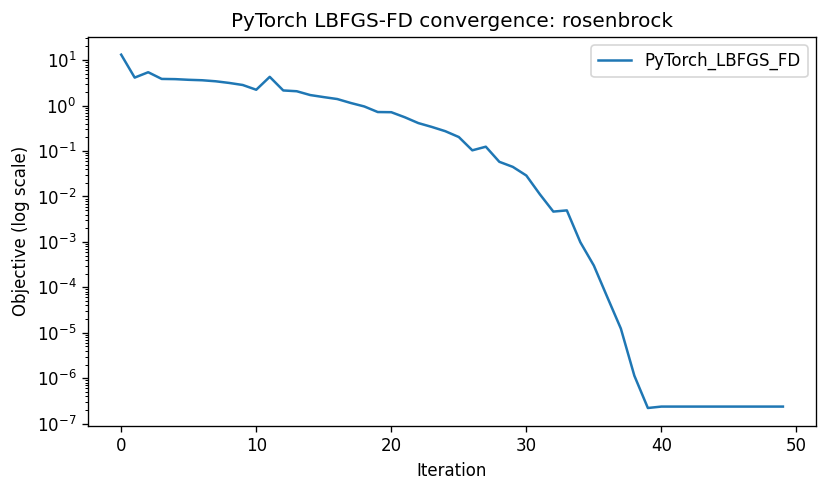

[PyTorch LBFGS-FD] iter 1/50 | f = 3.904241e-05
[PyTorch LBFGS-FD] iter 11/50 | f = 2.479865e-10
[PyTorch LBFGS-FD] iter 21/50 | f = 2.479865e-10
[PyTorch LBFGS-FD] iter 31/50 | f = 2.479865e-10
[PyTorch LBFGS-FD] iter 41/50 | f = 2.479865e-10
[PyTorch LBFGS-FD] iter 50/50 | f = 2.479865e-10

[rastrigin] Final f: 2.4798652020763257e-10
[rastrigin] Best x: [-4.99996523e-07 -4.99996523e-07 -4.99996523e-07 -4.99996523e-07
 -4.99996523e-07]
[rastrigin] Time (s): 0.0231


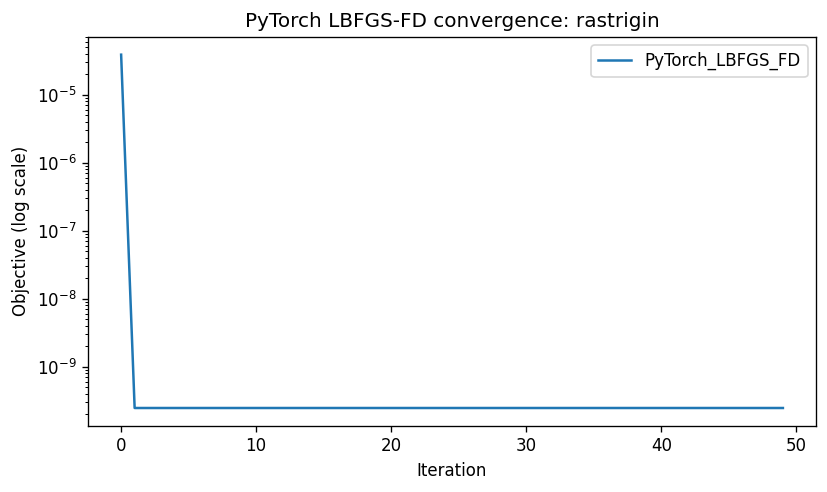

In [28]:
import matplotlib.pyplot as plt

# Paper benchmark functions
def rosenbrock(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

def rastrigin(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

problems = {
    "rosenbrock": {"f": rosenbrock, "bounds": [(-3.0, 3.0)] * 5},
    "rastrigin":  {"f": rastrigin,  "bounds": [(-5.12, 5.12)] * 5},
}

for name, info in problems.items():
    f = info["f"]
    bounds = info["bounds"]
    x0 = np.zeros(len(bounds))  # simple default init

    t0 = time.time()
    out = pytorch_lbfgs_fd(f, x0, bounds, outer_iters=50, verbose=True)
    t1 = time.time()

    print(f"\n[{name}] Final f:", out["f_best"])
    print(f"[{name}] Best x:", out["x_best"])
    print(f"[{name}] Time (s):", round(t1 - t0, 4))

    plt.figure()
    plt.plot(out["curve"], label="PyTorch_LBFGS_FD")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Objective (log scale)")
    plt.title(f"PyTorch LBFGS-FD convergence: {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()
